In [ ]:
# ============================================
# CS223A Lecture 5 — Stanford Arm Forward Kinematics
# Day 5
# ============================================

import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

# Today we implement the Stanford Arm — a real 6DOF robot
# Features: prismatic joint 3, spherical wrist (joints 4,5,6)

print("Day 5 — Stanford Arm Forward Kinematics")
print("="*45)

In [3]:
# --- Stanford Arm DH Parameters ---
# 6 DOF: joints 1,2 revolute, joint 3 prismatic, joints 4,5,6 revolute
# Joint 3 is prismatic — d3 is variable, not theta

# Joint variables (what we control)

theta1 = np.radians(0)
theta2 = np.radians(90)
d3 = 0.5    # <---------------- prismatic joint — linear extension in meters
theta4 = np.radians(0)
theta5 = np.radians(0)
theta6 = np.radians(0)

def DH_transform(a ,alpha,d,theta):
    ct = np.cos(theta)
    ca = np.cos(alpha)
    st = np.sin(theta)
    sa = np.sin(alpha)
    return np.array([
        [ct ,-st*ca ,st*sa ,a*ct],
        [st ,ct*ca ,-ca*sa ,a*st],
        [0 ,sa , ca , d],
        [0 ,0 ,0 ,1 ]
    ])

# Stanford Arm DH Table
# Link            a      alpha          d    theta
T1 = DH_transform(0,  np.radians(-90),  0,   theta1)
T2 = DH_transform(0,  np.radians(90),   0,   theta2)
T3 = DH_transform(0,  0,                d3,  0     )
T4 = DH_transform(0,  np.radians(-90),  0,   theta4)
T5 = DH_transform(0,  np.radians(90),   0,   theta5)
T6 = DH_transform(0,  0             ,   0,   theta6)

print("Individual joint transform computed .")
print("T1:\n", np.round(T1 ,3))
print("T2:\n", np.round(T2 ,3))
print("T3:\n", np.round(T3 ,3))

Individual joint transform computed .
T1:
 [[ 1. -0. -0.  0.]
 [ 0.  0.  0.  0.]
 [ 0. -1.  0.  0.]
 [ 0.  0.  0.  1.]]
T2:
 [[ 0. -0.  1.  0.]
 [ 1.  0. -0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  0.  1.]]
T3:
 [[ 1.  -0.   0.   0. ]
 [ 0.   1.  -0.   0. ]
 [ 0.   0.   1.   0.5]
 [ 0.   0.   0.   1. ]]


In [4]:
# --- Full Kinematic Chain ---

T0_6 = T1 @ T2 @ T3 @ T4 @ T5 @ T6

print("Full Stanford Arm Transform (T0_6):")
print(np.round(T0_6, 3))

# Extract end effector position
x = T0_6[0, 3]
y = T0_6[1, 3]
z = T0_6[2, 3]
print(f"\nEnd Effector Position:")
print(f"x = {round(x,3)} m")
print(f"y = {round(y,3)} m")
print(f"z = {round(z,3)} m")

# Extract end effector orientation (rotation matrix)
R = T0_6[:3, :3]
print(f"\nEnd Effector Orientation (Rotation Matrix):")
print(np.round(R, 3))

Full Stanford Arm Transform (T0_6):
[[ 0.   0.   0.   0.5]
 [ 0.   0.   0.   0. ]
 [-1.   0.   0.   0. ]
 [ 0.   0.   0.   1. ]]

End Effector Position:
x = 0.5 m
y = 0.0 m
z = 0.0 m

End Effector Orientation (Rotation Matrix):
[[ 0.  0.  0.]
 [ 0.  0.  0.]
 [-1.  0.  0.]]


In [7]:
# --- Move the arm to a different configuration ---
theta1 = np.radians(45)
theta2 = np.radians(45)
d3     = 0.8
theta4 = np.radians(30)
theta5 = np.radians(45)
theta6 = np.radians(0)

# Recompute transforms
T1 = DH_transform(0, np.radians(-90), 0,  theta1)
T2 = DH_transform(0, np.radians(90),  0,  theta2)
T3 = DH_transform(0, 0,               d3, 0)
T4 = DH_transform(0, np.radians(-90), 0,  theta4)
T5 = DH_transform(0, np.radians(90),  0,  theta5)
T6 = DH_transform(0, 0,               0,  theta6)

# Chain all transforms and get intermediate positions
T01 = T1
T02 = T1 @ T2 
T03 = T1 @ T2 @ T3 
T04 = T1 @ T2 @ T3 @ T4 
T05 = T1 @ T2 @ T3 @ T4 @ T5 
T06 = T1 @ T2 @ T3 @ T4 @ T5 @ T6 

#Extract position at each joint
positions = np.array([
    [0, 0, 0],                           # base
    [T01[0,3], T01[1,3], T01[2,3]],     # joint 1
    [T02[0,3], T02[1,3], T02[2,3]],     # joint 2
    [T03[0,3], T03[1,3], T03[2,3]],     # joint 3 (prismatic)
    [T04[0,3], T04[1,3], T04[2,3]],     # joint 4
    [T05[0,3], T05[1,3], T05[2,3]],     # joint 5
    [T06[0,3], T06[1,3], T06[2,3]],     # end effector
])

print("Joint Positions: ")
for i ,p in enumerate(positions):
    print(f"joint {i} : {np.round(p ,3)}")

print(f"\nEnd Effector: x = {round(T06[0 ,3],3)} ,y = {round(T06[1,3], 3)}, z = {round(T06[2,3],3)}")


Joint Positions: 
joint 0 : [0. 0. 0.]
joint 1 : [0. 0. 0.]
joint 2 : [0. 0. 0.]
joint 3 : [0.4 0.4 0. ]
joint 4 : [0.4 0.4 0. ]
joint 5 : [0.4 0.4 0. ]
joint 6 : [0.4 0.4 0. ]

End Effector: x = 0.4 ,y = 0.4, z = 0.0


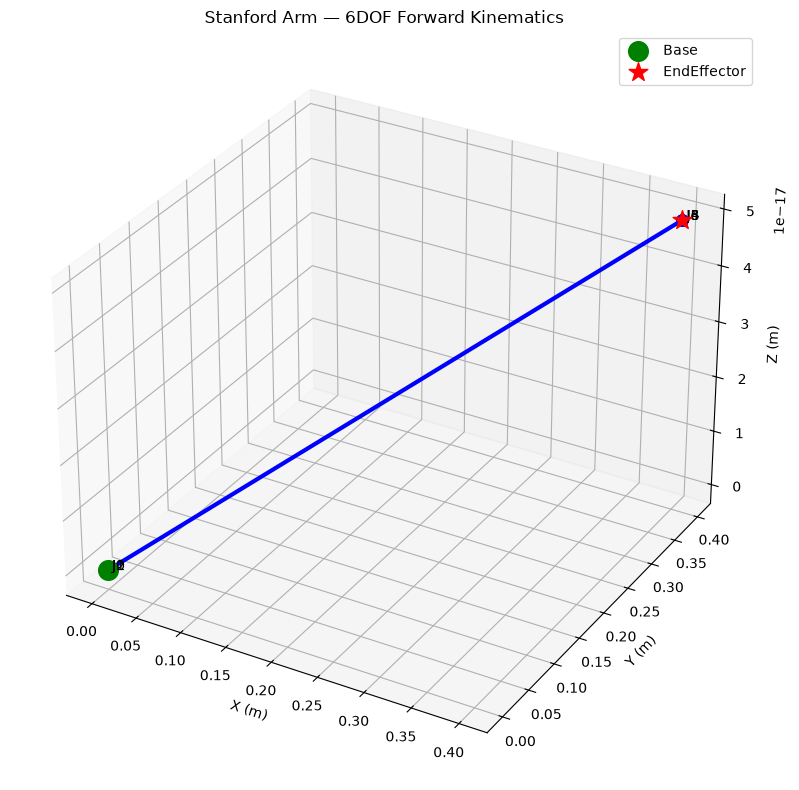

Stanford Arm visualized in 3D!


In [10]:
# ---- 3D visualization ----
fig = plt.figure(figsize= (10,8))
ax = fig.add_subplot(111, projection= '3d')

#plot the  arm links 
ax.plot(positions[:,0], positions[:,1 ] , positions[:,2], 'b-o' , linewidth =3,markersize = 8)

# Highlight Base and Endeffector 
ax.scatter(*positions[0], color= 'green' ,s=200 ,label = 'Base' ,zorder = 5)
ax.scatter(*positions[-1], color= 'red' ,s=200 , marker = '*', label = 'EndEffector' , zorder= 5)

# Label each joint 
for i , p in enumerate(positions):
    ax.text(p[0], p[1], p[2], f' J{i}' , fontsize=10)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Stanford Arm — 6DOF Forward Kinematics')
ax.legend()
plt.tight_layout()
plt.show()

print("Stanford Arm visualized in 3D!")
